In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
class_param = pd.read_csv('../data/classification_parameters.csv')
reservoir_info = pd.read_csv('../data/reservoir_info.csv')
well_data = pd.read_csv('../data/spe_africa_dseats_datathon_2025_wells_dataset.csv')
sample_sub = pd.read_csv('../data/Innovisors_DSEATS_Africa_2025_Classification.csv')

In [3]:
sample_sub.head(4)

,Well,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index
0,1,KEMA,Saturated,GL,Unsteady,aSolGOR,Flat,Decr
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
class_param

,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index Trend
0,ACHI,Saturated,NF,Steady,aSolGOR,Flat,Flat
1,KEMA,Undersat,GL,Unsteady,bSolGOR,Incr,Incr
2,MAKO,NaN,NaN,NaN,Combo,Decr,Decr
3,DEPU,NaN,NaN,NaN,NaN,Combo,Combo
4,JANI,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
reservoir_info

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [6]:
reservoir_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Reservoir Name                            5 non-null      object 
 1   Initial Reservoir Pressure (PSI)          5 non-null      object 
 2   Bubble Point Pressure (PSI)               5 non-null      object 
 3   Current Average Reservoir Pressure (PSI)  5 non-null      object 
 4   Solution Gas-Oil-Ratio (SCF/BBL)          5 non-null      object 
 5   Formation Volume Factor (RB/STB)          5 non-null      float64
dtypes: float64(1), object(5)
memory usage: 372.0+ bytes


In [7]:
cols = reservoir_info.columns.drop('Reservoir Name').to_list()
cols

['Initial Reservoir Pressure (PSI)',
 'Bubble Point Pressure (PSI)',
 'Current Average Reservoir Pressure (PSI)',
 'Solution Gas-Oil-Ratio (SCF/BBL)',
 'Formation Volume Factor (RB/STB)']

In [8]:
# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )

In [9]:
# Apply to production columns
for col in cols:
    reservoir_info[col] = pd.to_numeric(clean_numeric_column(reservoir_info[col]), errors='coerce')

In [10]:
# Check data types after conversion
print("Data types after conversion:")
print(reservoir_info.dtypes)

Data types after conversion:
Reservoir Name                               object
Initial Reservoir Pressure (PSI)              int64
Bubble Point Pressure (PSI)                   int64
Current Average Reservoir Pressure (PSI)      int64
Solution Gas-Oil-Ratio (SCF/BBL)              int64
Formation Volume Factor (RB/STB)            float64
dtype: object


In [11]:
well_data.head(10)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0
5,20-Feb-14,Well_#1,0.0,"3,964",190.181,0,0.00000,58.036,47.878,0,0,0,0
6,21-Feb-14,Well_#1,0.0,"3,972",189.939,0,39.99891,304.692,47.938,0,0,0,0
7,22-Feb-14,Well_#1,0.0,"3,978",189.609,0,0.00000,453.734,49.351,0,0,0,0
8,23-Feb-14,Well_#1,0.0,"3,985",189.435,0,0.42376,667.13,49.351,0,0,0,0
9,24-Feb-14,Well_#1,0.0,"4,096",189.343,0,0.44066,440.036,49.316,0,0,0,0


In [12]:
well_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7955 entries, 0 to 7954
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROD_DATE                             7955 non-null   object 
 1   WELL_NAME                             7955 non-null   object 
 2   ON_STREAM_HRS                         7955 non-null   float64
 3   BOTTOMHOLE_FLOWING_PRESSURE (PSI)     7955 non-null   object 
 4   DOWNHOLE_TEMPERATURE (deg F)          7955 non-null   float64
 5   ANNULUS_PRESS (PSI)                   7955 non-null   object 
 6   CHOKE_SIZE (%)                        7955 non-null   float64
 7   WELL_HEAD_PRESSURE (PSI)              7955 non-null   object 
 8   WELL_HEAD_TEMPERATURE (deg F)         7955 non-null   float64
 9   CUMULATIVE_OIL_PROD (STB)             7955 non-null   object 
 10  CUMULATIVE_FORMATION_GAS_PROD (MSCF)  7955 non-null   object 
 11  CUMULATIVE_TOTAL_

In [13]:
well_data.describe(include='all')

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
count,7955,7955,7955.000000,7955,7955.000000,7955,7955.000000,7955,7955.000000,7955,7955,7955,7955
unique,2004,20,NaN,2052,NaN,5216,NaN,7113,NaN,7053,7033,7040,6775
top,05-Apr-13,Well_#20,NaN,0,NaN,0,NaN,0,NaN,0,0,0,0
freq,7,820,NaN,64,NaN,1888,NaN,40,NaN,396,396,396,513
mean,NaN,NaN,21.623497,NaN,168.757429,NaN,56.155295,NaN,86.836365,NaN,NaN,NaN,NaN
std,NaN,NaN,6.567826,NaN,31.917787,NaN,34.975408,NaN,22.738615,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,24.000000,NaN,150.228500,NaN,28.130855,NaN,80.677500,NaN,NaN,NaN,NaN
50%,NaN,NaN,24.000000,NaN,158.624000,NaN,51.068030,NaN,88.364000,NaN,NaN,NaN,NaN
75%,NaN,NaN,24.000000,NaN,202.600000,NaN,99.800950,NaN,96.770500,NaN,NaN,NaN,NaN


In [14]:
# Check for non-numeric patterns in pressure columns
pressure_cols = ['BOTTOMHOLE_FLOWING_PRESSURE (PSI)', 'ANNULUS_PRESS (PSI)', 'WELL_HEAD_PRESSURE (PSI)']

# Check cumulative production columns
prod_cols = ['CUMULATIVE_OIL_PROD (STB)', 'CUMULATIVE_FORMATION_GAS_PROD (MSCF)', 
             'CUMULATIVE_TOTAL_GAS_PROD (MSCF)', 'CUMULATIVE_WATER_PROD (BBL)']

# Function to clean numeric columns (handles commas, spaces, etc.)
def clean_numeric_column(series):
    return (series.astype(str)
            .str.replace(',', '')  # Remove commas
            .str.replace(' ', '')   # Remove spaces
            .str.strip()           # Remove leading/trailing whitespace
    )

In [15]:
# Apply to production columns
for col in prod_cols:
    well_data[col] = pd.to_numeric(clean_numeric_column(well_data[col]), errors='coerce')

In [16]:
# Apply to pressure columns
for col in pressure_cols:
    well_data[col] = pd.to_numeric(clean_numeric_column(well_data[col]), errors='coerce')

In [17]:
# Convert date column (adjust format based on what you see)
well_data['PROD_DATE'] = pd.to_datetime(well_data['PROD_DATE'], errors='coerce')

In [18]:
# Check data types after conversion
print("Data types after conversion:")
print(well_data.dtypes)

Data types after conversion:
PROD_DATE                               datetime64[ns]
WELL_NAME                                       object
ON_STREAM_HRS                                  float64
BOTTOMHOLE_FLOWING_PRESSURE (PSI)                int64
DOWNHOLE_TEMPERATURE (deg F)                   float64
ANNULUS_PRESS (PSI)                            float64
CHOKE_SIZE (%)                                 float64
WELL_HEAD_PRESSURE (PSI)                       float64
WELL_HEAD_TEMPERATURE (deg F)                  float64
CUMULATIVE_OIL_PROD (STB)                        int64
CUMULATIVE_FORMATION_GAS_PROD (MSCF)             int64
CUMULATIVE_TOTAL_GAS_PROD (MSCF)                 int64
CUMULATIVE_WATER_PROD (BBL)                      int64
dtype: object


In [19]:
# Validate realistic ranges
print("\nPressure range:")
for col in pressure_cols:
    print(f"{col}: {well_data[col].min():.1f} - {well_data[col].max():.1f}")

print("\nProduction ranges:")
for col in prod_cols:
    print(f"{col}: {well_data[col].min():.1f} - {well_data[col].max():.1f}")


Pressure range:
BOTTOMHOLE_FLOWING_PRESSURE (PSI): 0.0 - 4096.0
ANNULUS_PRESS (PSI): 0.0 - 1639.0
WELL_HEAD_PRESSURE (PSI): 0.0 - 1787.8

Production ranges:
CUMULATIVE_OIL_PROD (STB): 0.0 - 1129301.0
CUMULATIVE_FORMATION_GAS_PROD (MSCF): 0.0 - 1458660.0
CUMULATIVE_TOTAL_GAS_PROD (MSCF): 0.0 - 1458660.0
CUMULATIVE_WATER_PROD (BBL): 0.0 - 1499262.0


In [20]:
well_data.head(4)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
0,2014-02-15,Well_#1,0.0,4050,189.866,0.0,1.17951,482.460,50.864,0,0,0,0
1,2014-02-16,Well_#1,0.0,3961,189.945,0.0,2.99440,328.601,47.668,0,0,0,0
2,2014-02-17,Well_#1,0.0,3961,190.004,0.0,1.90349,387.218,48.962,0,0,0,0
3,2014-02-18,Well_#1,0.0,3964,190.020,0.0,0.00000,308.980,46.636,0,0,0,0


In [21]:
missing_count = well_data.isnull().sum()
missing_count

PROD_DATE                               0
WELL_NAME                               0
ON_STREAM_HRS                           0
BOTTOMHOLE_FLOWING_PRESSURE (PSI)       0
DOWNHOLE_TEMPERATURE (deg F)            0
ANNULUS_PRESS (PSI)                     0
CHOKE_SIZE (%)                          0
WELL_HEAD_PRESSURE (PSI)                0
WELL_HEAD_TEMPERATURE (deg F)           0
CUMULATIVE_OIL_PROD (STB)               0
CUMULATIVE_FORMATION_GAS_PROD (MSCF)    0
CUMULATIVE_TOTAL_GAS_PROD (MSCF)        0
CUMULATIVE_WATER_PROD (BBL)             0
dtype: int64

In [22]:
well_data.describe(include="all")

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
count,7955,7955,7955.000000,7955.000000,7955.000000,7955.000000,7955.000000,7955.000000,7955.000000,7.955000e+03,7.955000e+03,7.955000e+03,7.955000e+03
unique,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Well_#20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2013-08-26 16:25:49.516027648,NaN,21.623497,2613.811816,168.757429,471.339542,56.155295,212.574151,86.836365,1.725855e+05,1.456235e+05,1.811090e+05,1.427100e+05
min,2011-02-17 00:00:00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2012-08-02 00:00:00,NaN,24.000000,2195.000000,150.228500,4.199000,28.130855,68.661500,80.677500,4.769100e+04,3.854150e+04,4.152100e+04,8.907000e+03
50%,2013-06-25 00:00:00,NaN,24.000000,2465.000000,158.624000,301.247000,51.068030,113.718000,88.364000,1.092950e+05,1.016100e+05,1.171430e+05,4.651700e+04
75%,2014-10-01 00:00:00,NaN,24.000000,3067.000000,202.600000,981.329000,99.800950,161.176500,96.770500,2.424885e+05,1.991035e+05,2.707540e+05,1.949390e+05
max,2016-08-12 00:00:00,NaN,25.000000,4096.000000,212.153000,1639.040000,100.000000,1787.760000,182.157000,1.129301e+06,1.458660e+06,1.458660e+06,1.499262e+06


In [23]:
well_data['DAY'] = well_data['PROD_DATE'].dt.day_name()
well_data['MONTH'] = well_data['PROD_DATE'].dt.month_name()
well_data['Year'] = well_data['PROD_DATE'].dt.year
well_data.head(5)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),DAY,MONTH,Year
0,2014-02-15,Well_#1,0.0,4050,189.866,0.0,1.17951,482.460,50.864,0,0,0,0,Saturday,February,2014
1,2014-02-16,Well_#1,0.0,3961,189.945,0.0,2.99440,328.601,47.668,0,0,0,0,Sunday,February,2014
2,2014-02-17,Well_#1,0.0,3961,190.004,0.0,1.90349,387.218,48.962,0,0,0,0,Monday,February,2014
3,2014-02-18,Well_#1,0.0,3964,190.020,0.0,0.00000,308.980,46.636,0,0,0,0,Tuesday,February,2014
4,2014-02-19,Well_#1,0.0,3965,190.107,0.0,30.20760,196.057,47.297,0,0,0,0,Wednesday,February,2014


In [24]:
# Print min and max dates
print("Min date:", well_data['PROD_DATE'].min())
print("Max date:", well_data['PROD_DATE'].max())

Min date: 2011-02-17 00:00:00
Max date: 2016-08-12 00:00:00


In [25]:
#No of records per well
wells = well_data['WELL_NAME'].unique()
wells = list(wells)
for well in wells:
    count = (well_data['WELL_NAME'] == well).sum()
    print(f'{well}: {count}')

Well_#1: 204
Well_#2: 477
Well_#3: 124
Well_#4: 290
Well_#5: 314
Well_#6: 662
Well_#7: 524
Well_#8: 372
Well_#9: 582
Well_#10: 427
Well_#11: 341
Well_#12: 771
Well_#13: 247
Well_#14: 184
Well_#15: 327
Well_#16: 294
Well_#17: 436
Well_#18: 312
Well_#19: 247
Well_#20: 820


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_single_well_time_series(well_data, well_name, columns, title=None, ylabel="Value"):
    """
    Plot time series of specified columns for a single well.

    Parameters:
        well_data (pd.DataFrame): DataFrame containing 'PROD_DATE' and 'WELL_NAME'
        well_name (str): Name of the well to plot (e.g., "Well_#1")
        columns (list): List of column names to plot
        title (str): Optional title for the plot
        ylabel (str): Y-axis label
    """
    # Make a copy and sort
    well_data = well_data.copy()
    well_data['PROD_DATE'] = pd.to_datetime(well_data['PROD_DATE'])
    well_data = well_data.sort_values(['WELL_NAME', 'PROD_DATE'])

    # Filter for selected well
    well_well_data = well_data[well_data['WELL_NAME'] == well_name]

    if well_well_data.empty:
        print(f"Warning: No data found for {well_name}")
        return

    # Set title
    if title is None:
        title = f"{well_name} - Time Series Plot"

    # Plot
    plt.figure(figsize=(12, 5))
    for col in columns:
        if col in well_well_data.columns:
            plt.plot(well_well_data['PROD_DATE'], well_well_data[col], label=col, linewidth=1.5, marker='o')
        else:
            print(f"Column '{col}' not found in dataset.")

    plt.title(title, fontsize=14)
    plt.xlabel('Production Date')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


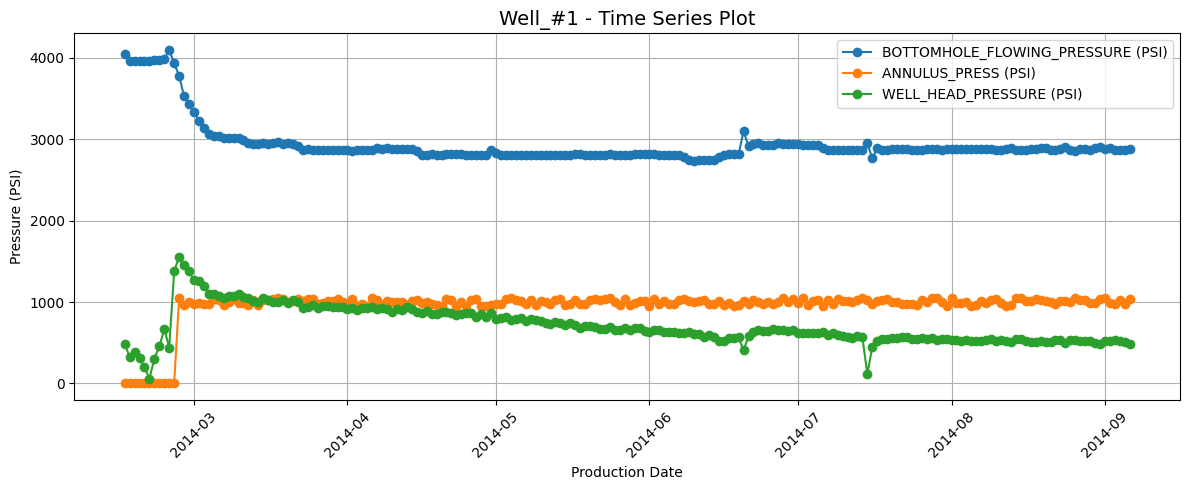

In [27]:
plot_single_well_time_series(
    well_data=well_data,
    well_name='Well_#1',
    columns=[
        'BOTTOMHOLE_FLOWING_PRESSURE (PSI)',
        'ANNULUS_PRESS (PSI)',
        'WELL_HEAD_PRESSURE (PSI)'
    ],
    ylabel='Pressure (PSI)'
)

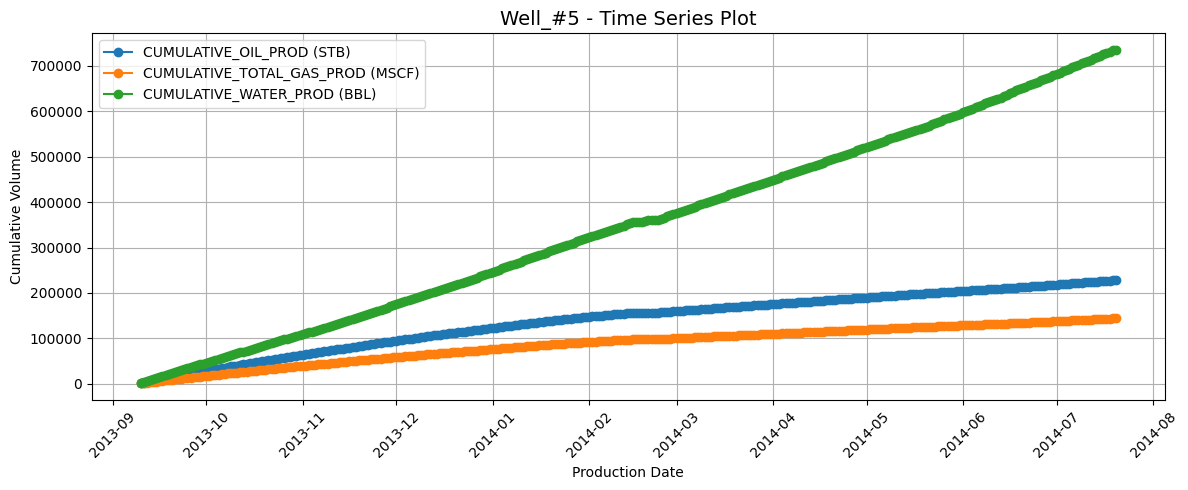

In [28]:
plot_single_well_time_series(
    well_data=well_data,
    well_name='Well_#5',
    columns=[
        'CUMULATIVE_OIL_PROD (STB)',
        'CUMULATIVE_TOTAL_GAS_PROD (MSCF)',
        'CUMULATIVE_WATER_PROD (BBL)'
    ],
    ylabel='Cumulative Volume'
)

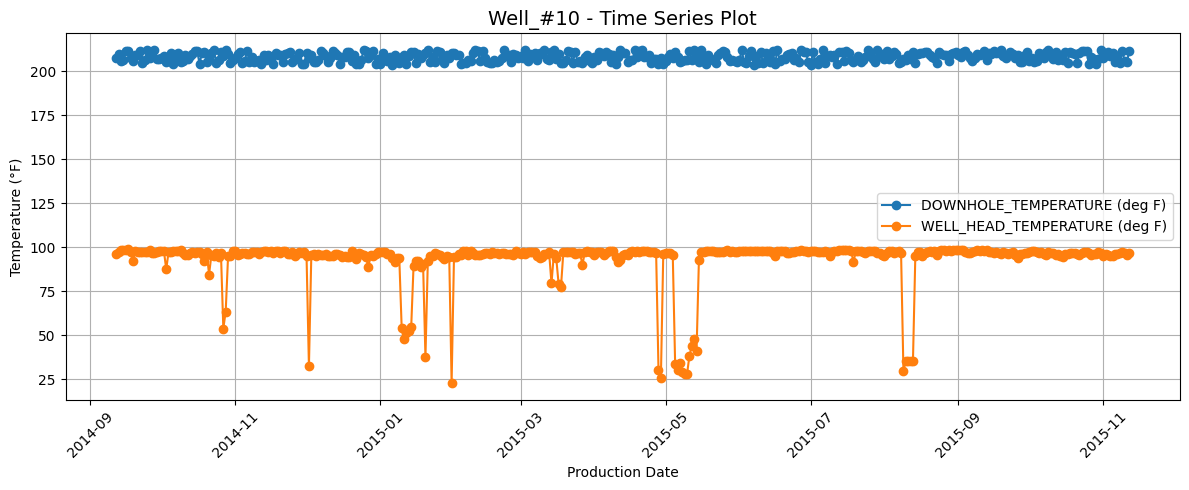

In [29]:
plot_single_well_time_series(
    well_data=well_data,
    well_name='Well_#10',
    columns=[
        'DOWNHOLE_TEMPERATURE (deg F)',
        'WELL_HEAD_TEMPERATURE (deg F)'
    ],
    ylabel='Temperature (°F)'
)

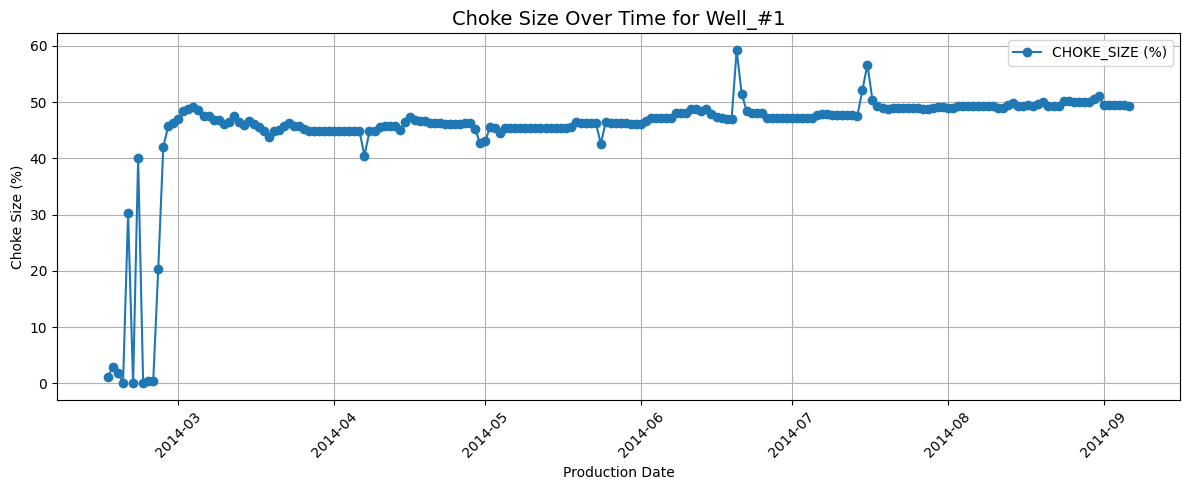

In [30]:
plot_single_well_time_series(
    well_data=well_data,
    well_name='Well_#1',
    columns=['CHOKE_SIZE (%)'],
    title="Choke Size Over Time for Well_#1",
    ylabel="Choke Size (%)"
)

In [31]:
import matplotlib.pyplot as plt
import re

def extract_number(well_name):
    """Extract numeric index from well name for sorting."""
    match = re.search(r'\d+', str(well_name))
    return int(match.group()) if match else float('inf')

def plot_well_time_series(well_data, columns, title="Time Series Plot", ylabel="Value", 
                         show_well_numbers=True, text_position=(0.02, 0.98), text_fontsize=12):
    """
    Plots time series of specified columns for each well in subplots.
    Parameters:
        well_data (pd.DataFrame): Data containing 'PROD_DATE' and 'WELL_NAME'
        columns (list): List of column names to plot on y-axis
        title (str): Super title of the plot
        ylabel (str): Label for y-axis
        show_well_numbers (bool): Whether to show well numbers on subplots
        text_position (tuple): (x, y) position for well number text in axes coordinates
        text_fontsize (int): Font size for well number text
    """
    well_data = well_data.copy()
    well_data['PROD_DATE'] = pd.to_datetime(well_data['PROD_DATE'])
    well_data = well_data.sort_values(['WELL_NAME', 'PROD_DATE'])
    
    wells = sorted(well_data['WELL_NAME'].dropna().unique(), key=extract_number)
    n_wells = len(wells)
    
    # Define subplot grid
    n_cols = 4
    n_rows = (n_wells + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4), sharex=False)
    axes = axes.flatten()
    
    for idx, well in enumerate(wells):
        ax = axes[idx]
        well_well_data = well_data[well_data['WELL_NAME'] == well]
        
        for col in columns:
            if col in well_well_data.columns:
                ax.plot(well_well_data['PROD_DATE'], well_well_data[col], label=col, linewidth=1, marker='o')
        
        # Add bold well number at the top of each subplot (if enabled)
        if show_well_numbers:
            ax.text(text_position[0], text_position[1], f"Well #{idx+1}", 
                   transform=ax.transAxes, fontsize=text_fontsize, fontweight='bold', 
                   verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', 
                   facecolor='white', alpha=0.8))
        
        ax.set_title(f"{well}", fontsize=10)
        ax.grid(True)
        ax.tick_params(axis='x', rotation=45)
        
        if idx % n_cols == 0:
            ax.set_ylabel(ylabel)
        if idx >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Production Date')
    
    # Remove unused axes
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Shared legend
    fig.legend(columns, loc='upper center', ncol=len(columns), fontsize=12)
    
    # Layout adjustment
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.suptitle(title, fontsize=16)
    plt.show()

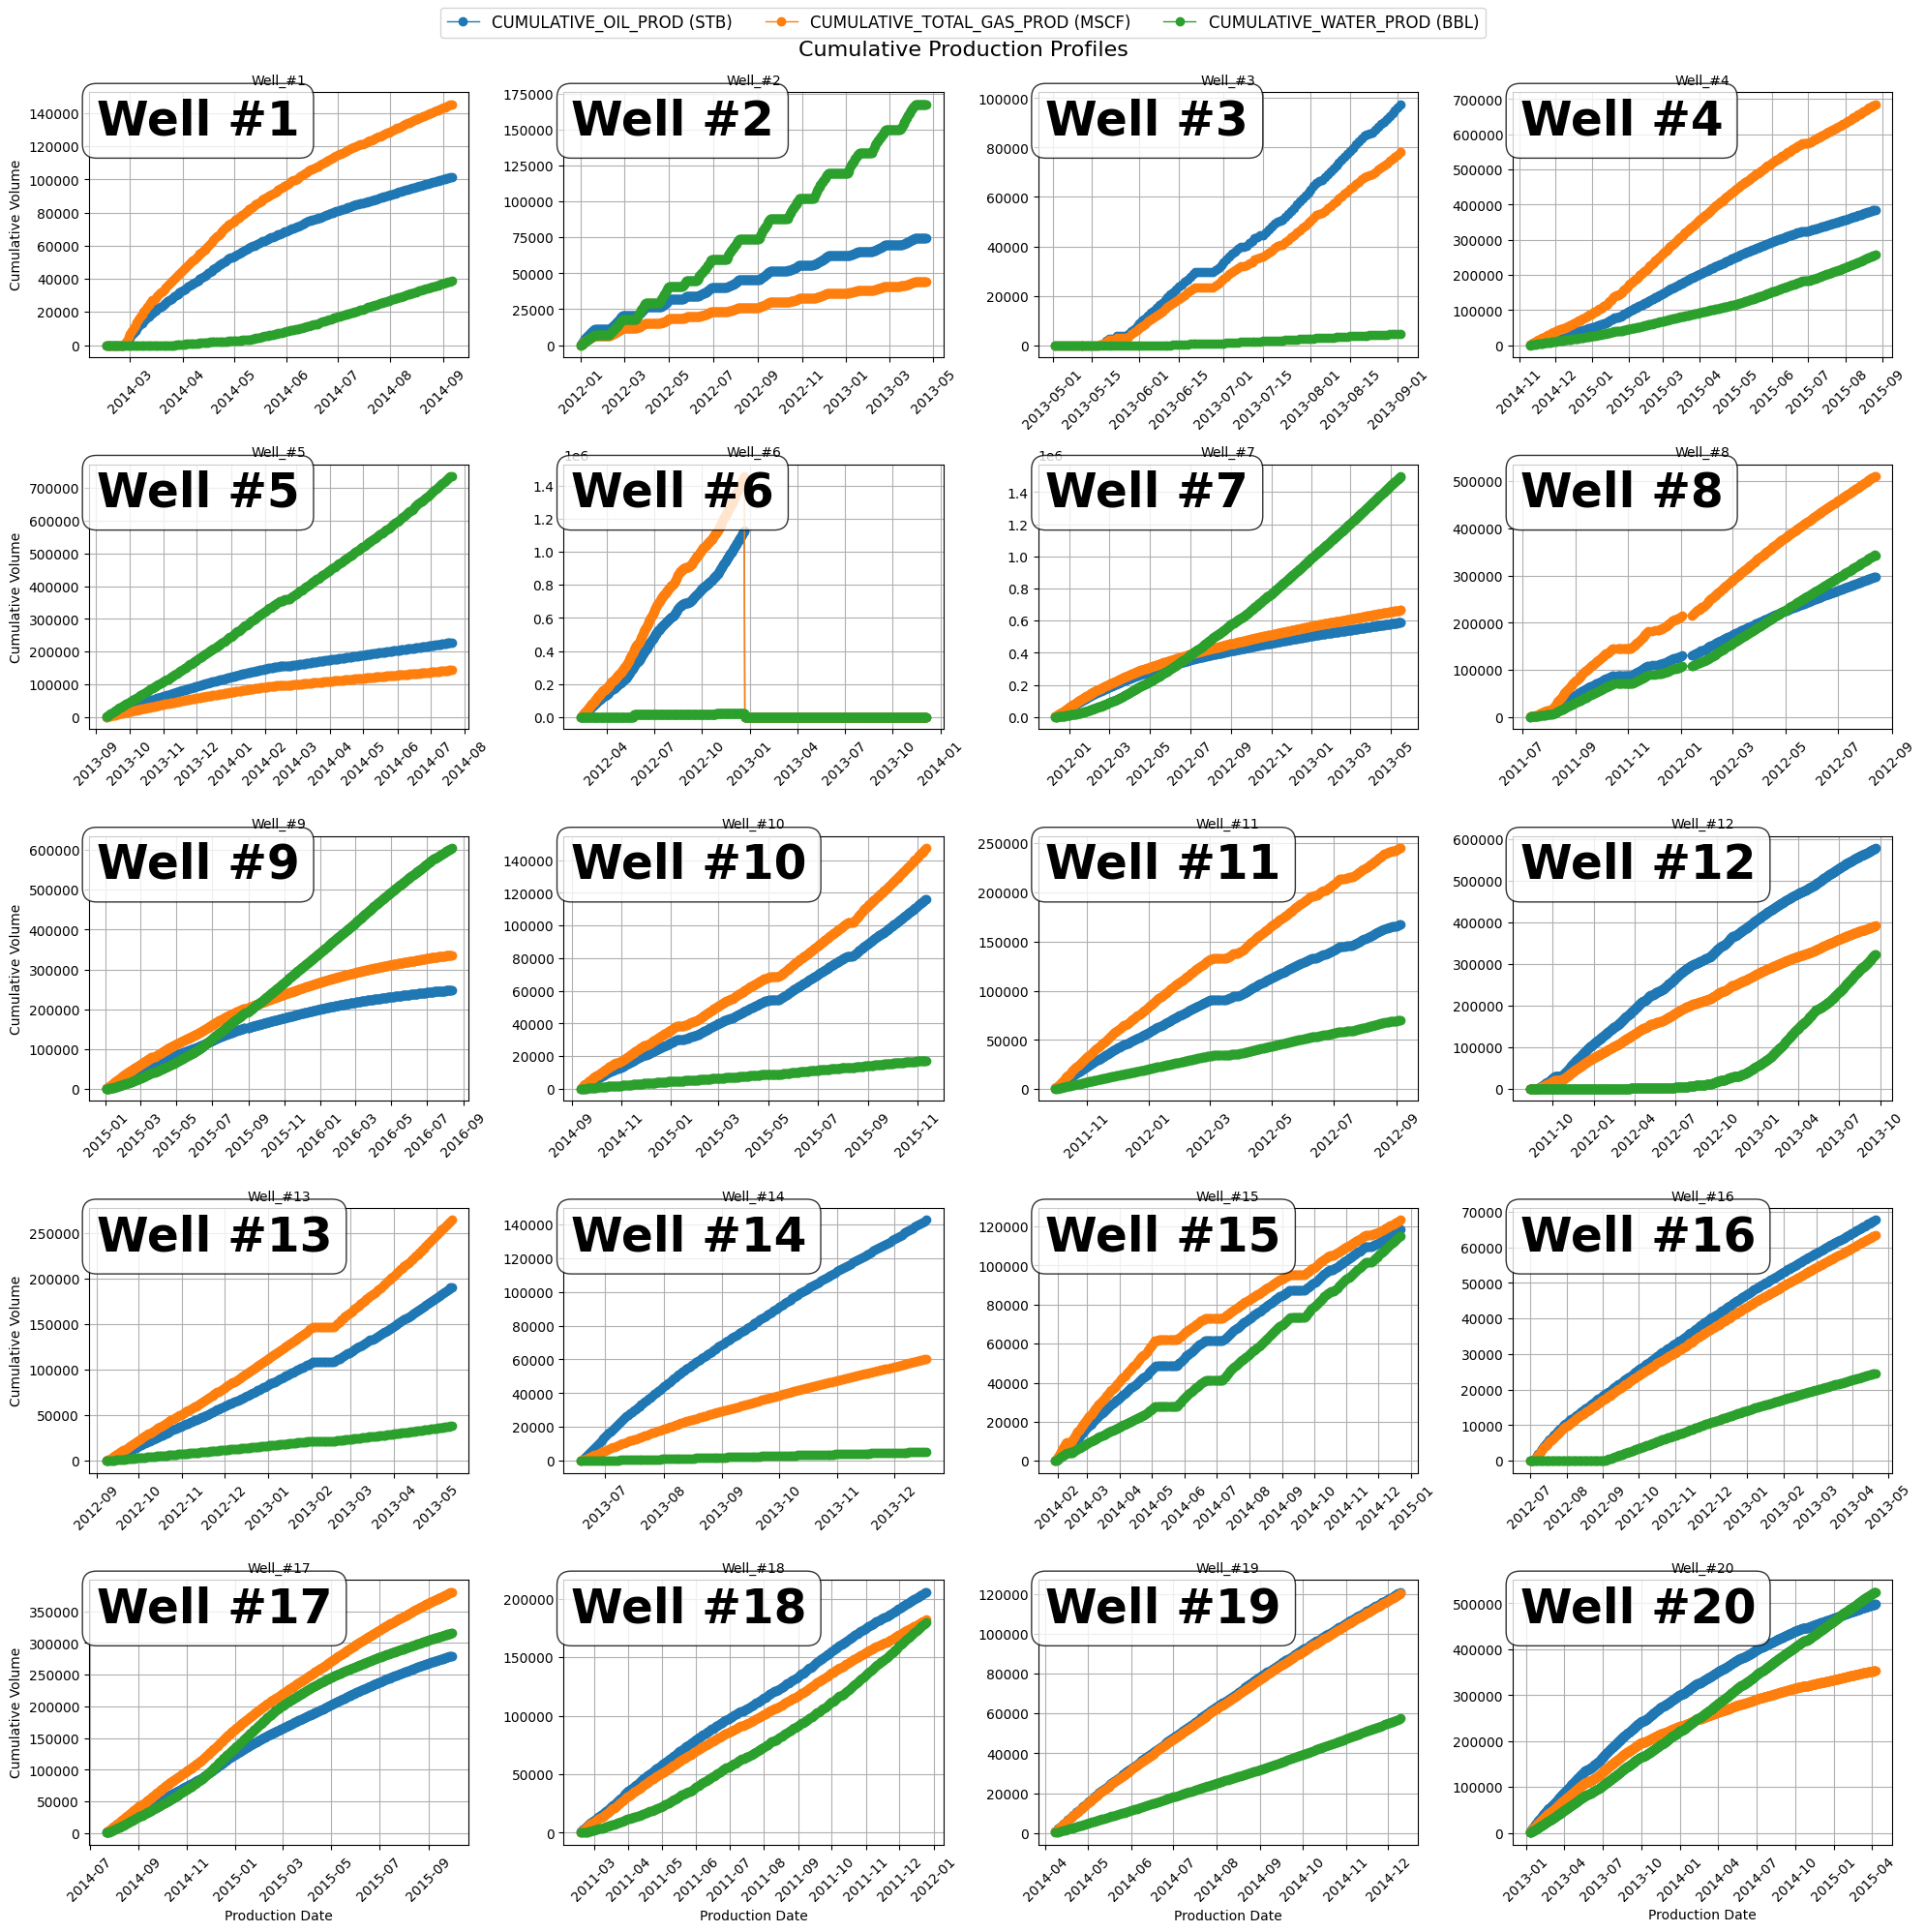

In [32]:
plot_well_time_series(
    well_data=well_data,
    columns=[
        'CUMULATIVE_OIL_PROD (STB)',
        'CUMULATIVE_TOTAL_GAS_PROD (MSCF)',
        'CUMULATIVE_WATER_PROD (BBL)'
    ],
    title="Cumulative Production Profiles",
    ylabel="Cumulative Volume",
    show_well_numbers=True,        # Turn on/off well numbers
    text_position=(0.02, 0.98),   # Position as (x, y) in axes coordinates
    text_fontsize=35               # Font size for well numbers
)

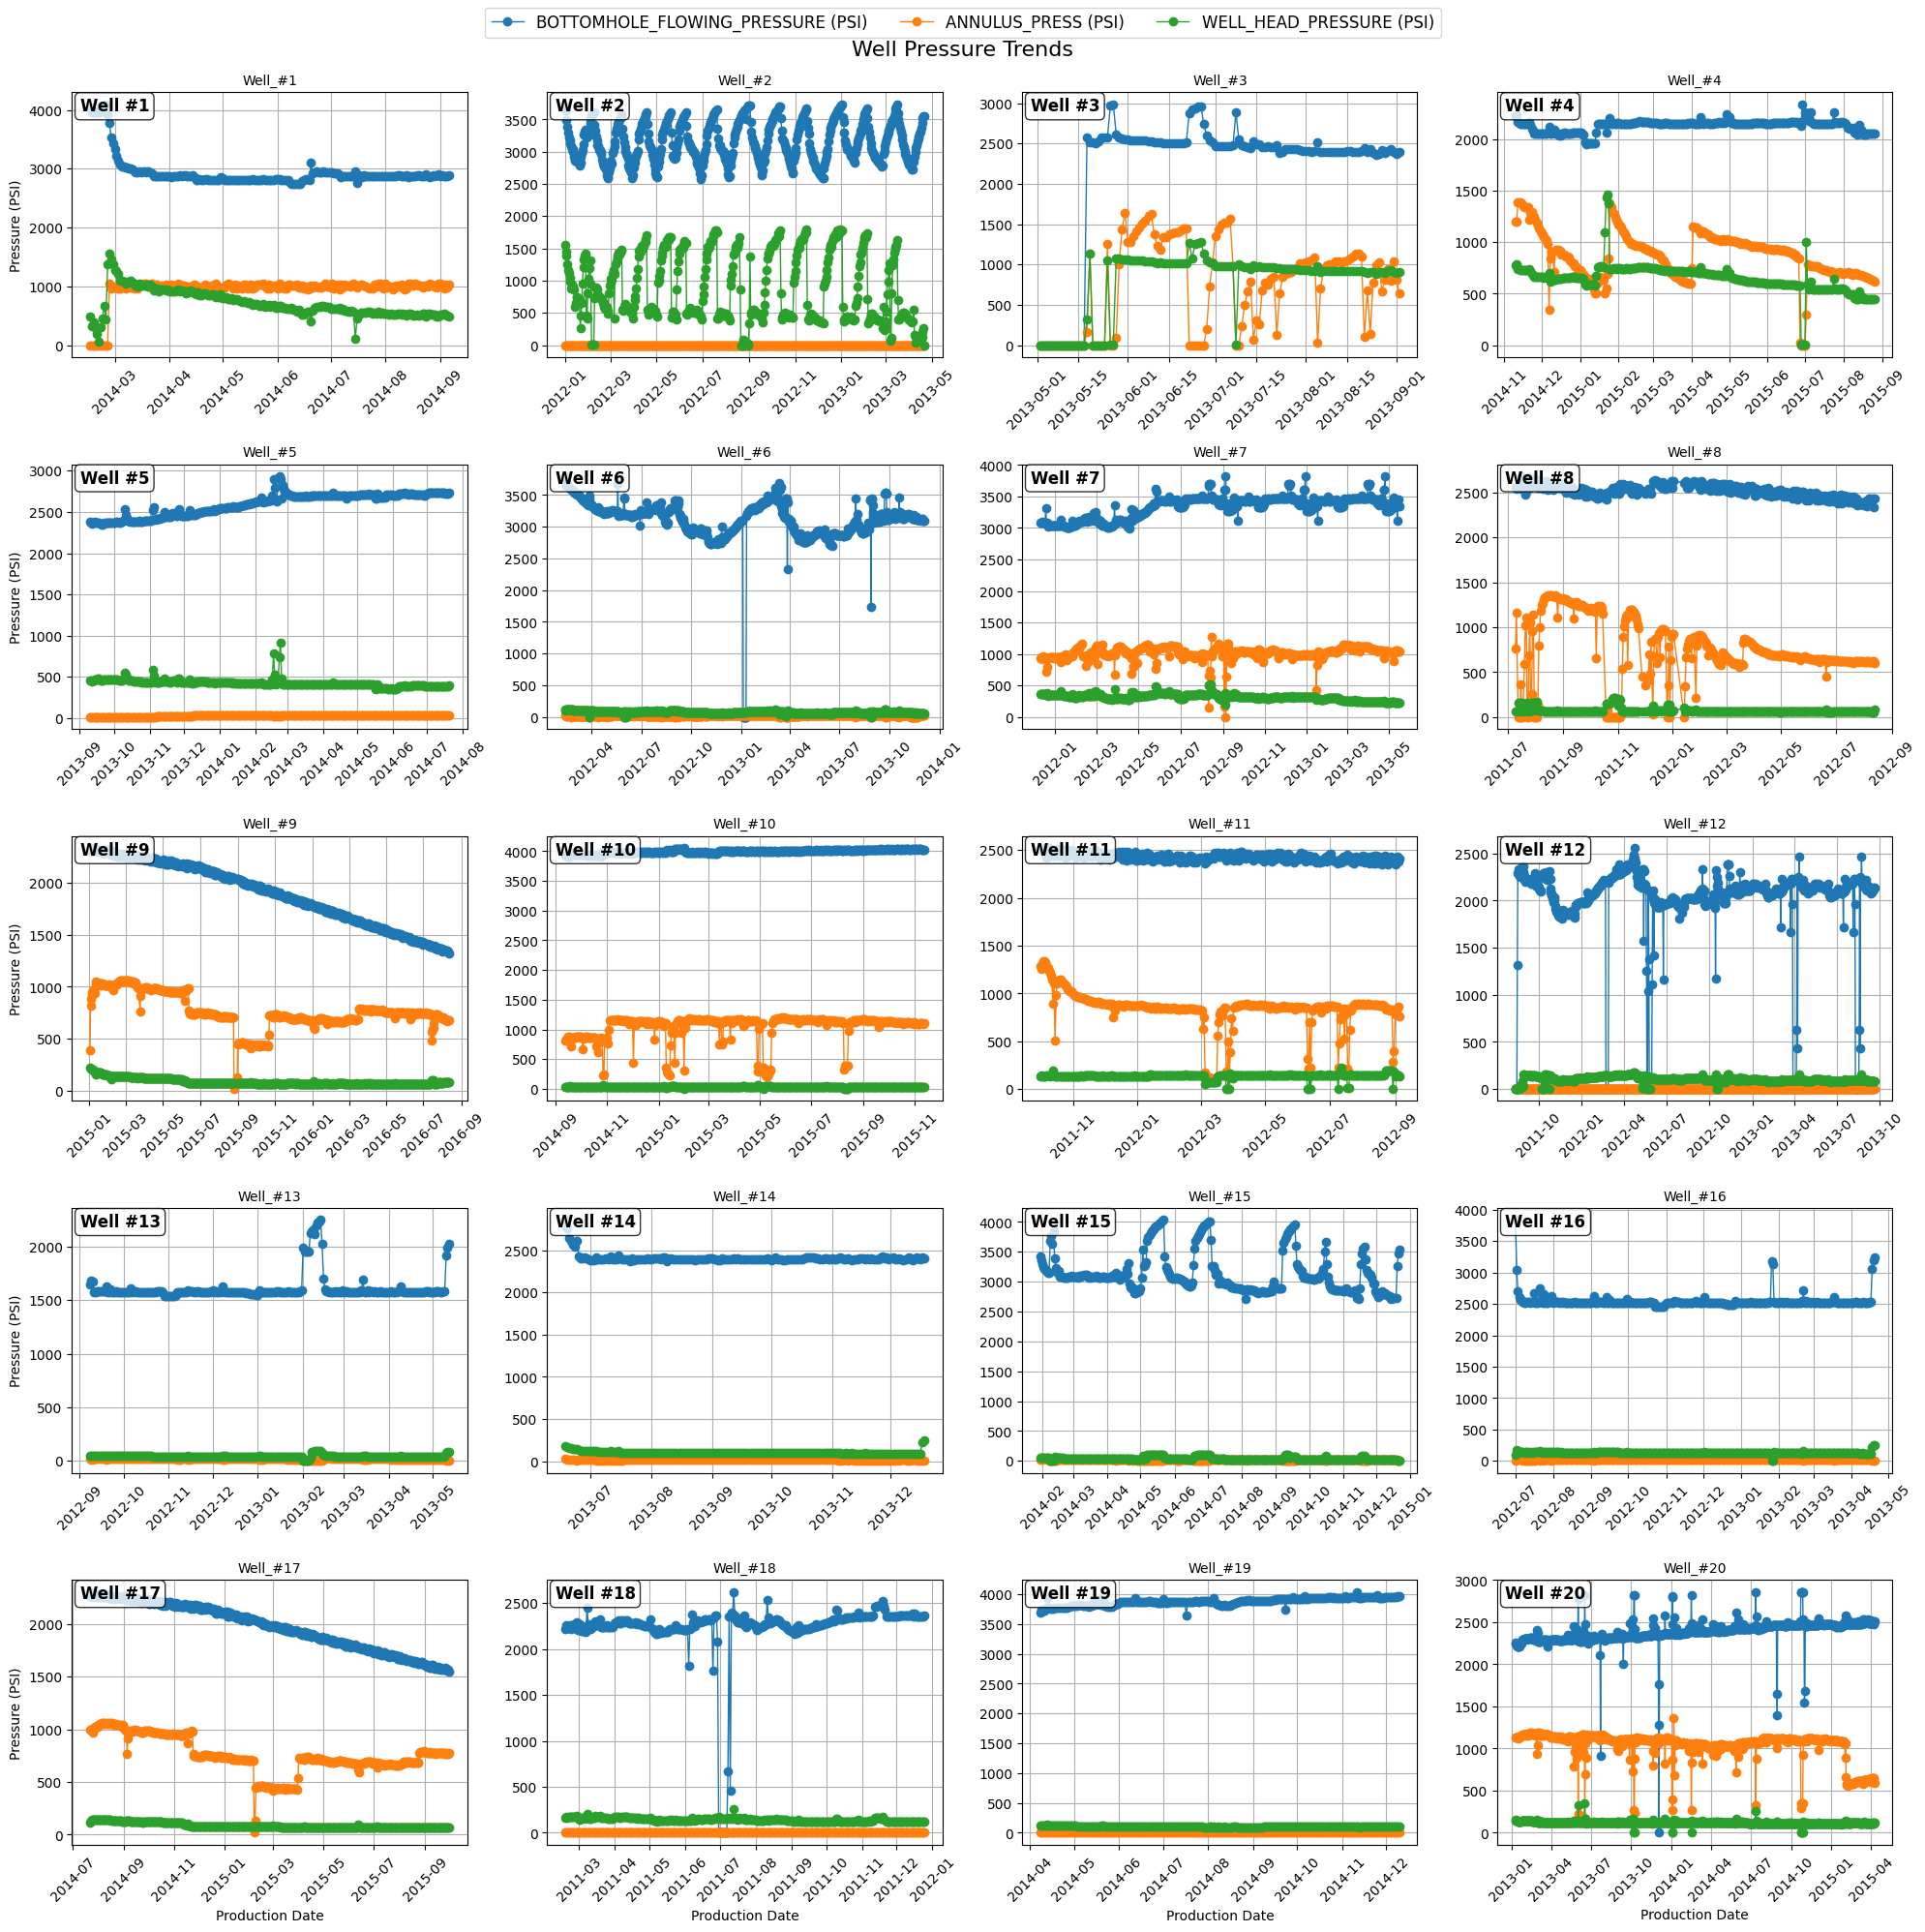

In [33]:
plot_well_time_series(
    well_data=well_data,
    columns=[
        'BOTTOMHOLE_FLOWING_PRESSURE (PSI)',
        'ANNULUS_PRESS (PSI)',
        'WELL_HEAD_PRESSURE (PSI)'
    ],
    title="Well Pressure Trends",
    ylabel="Pressure (PSI)",
    show_well_numbers=True,        # Turn on/off well numbers
    text_position=(0.02, 0.98),   # Position as (x, y) in axes coordinates
    text_fontsize=12               # Font size for well numbers
)

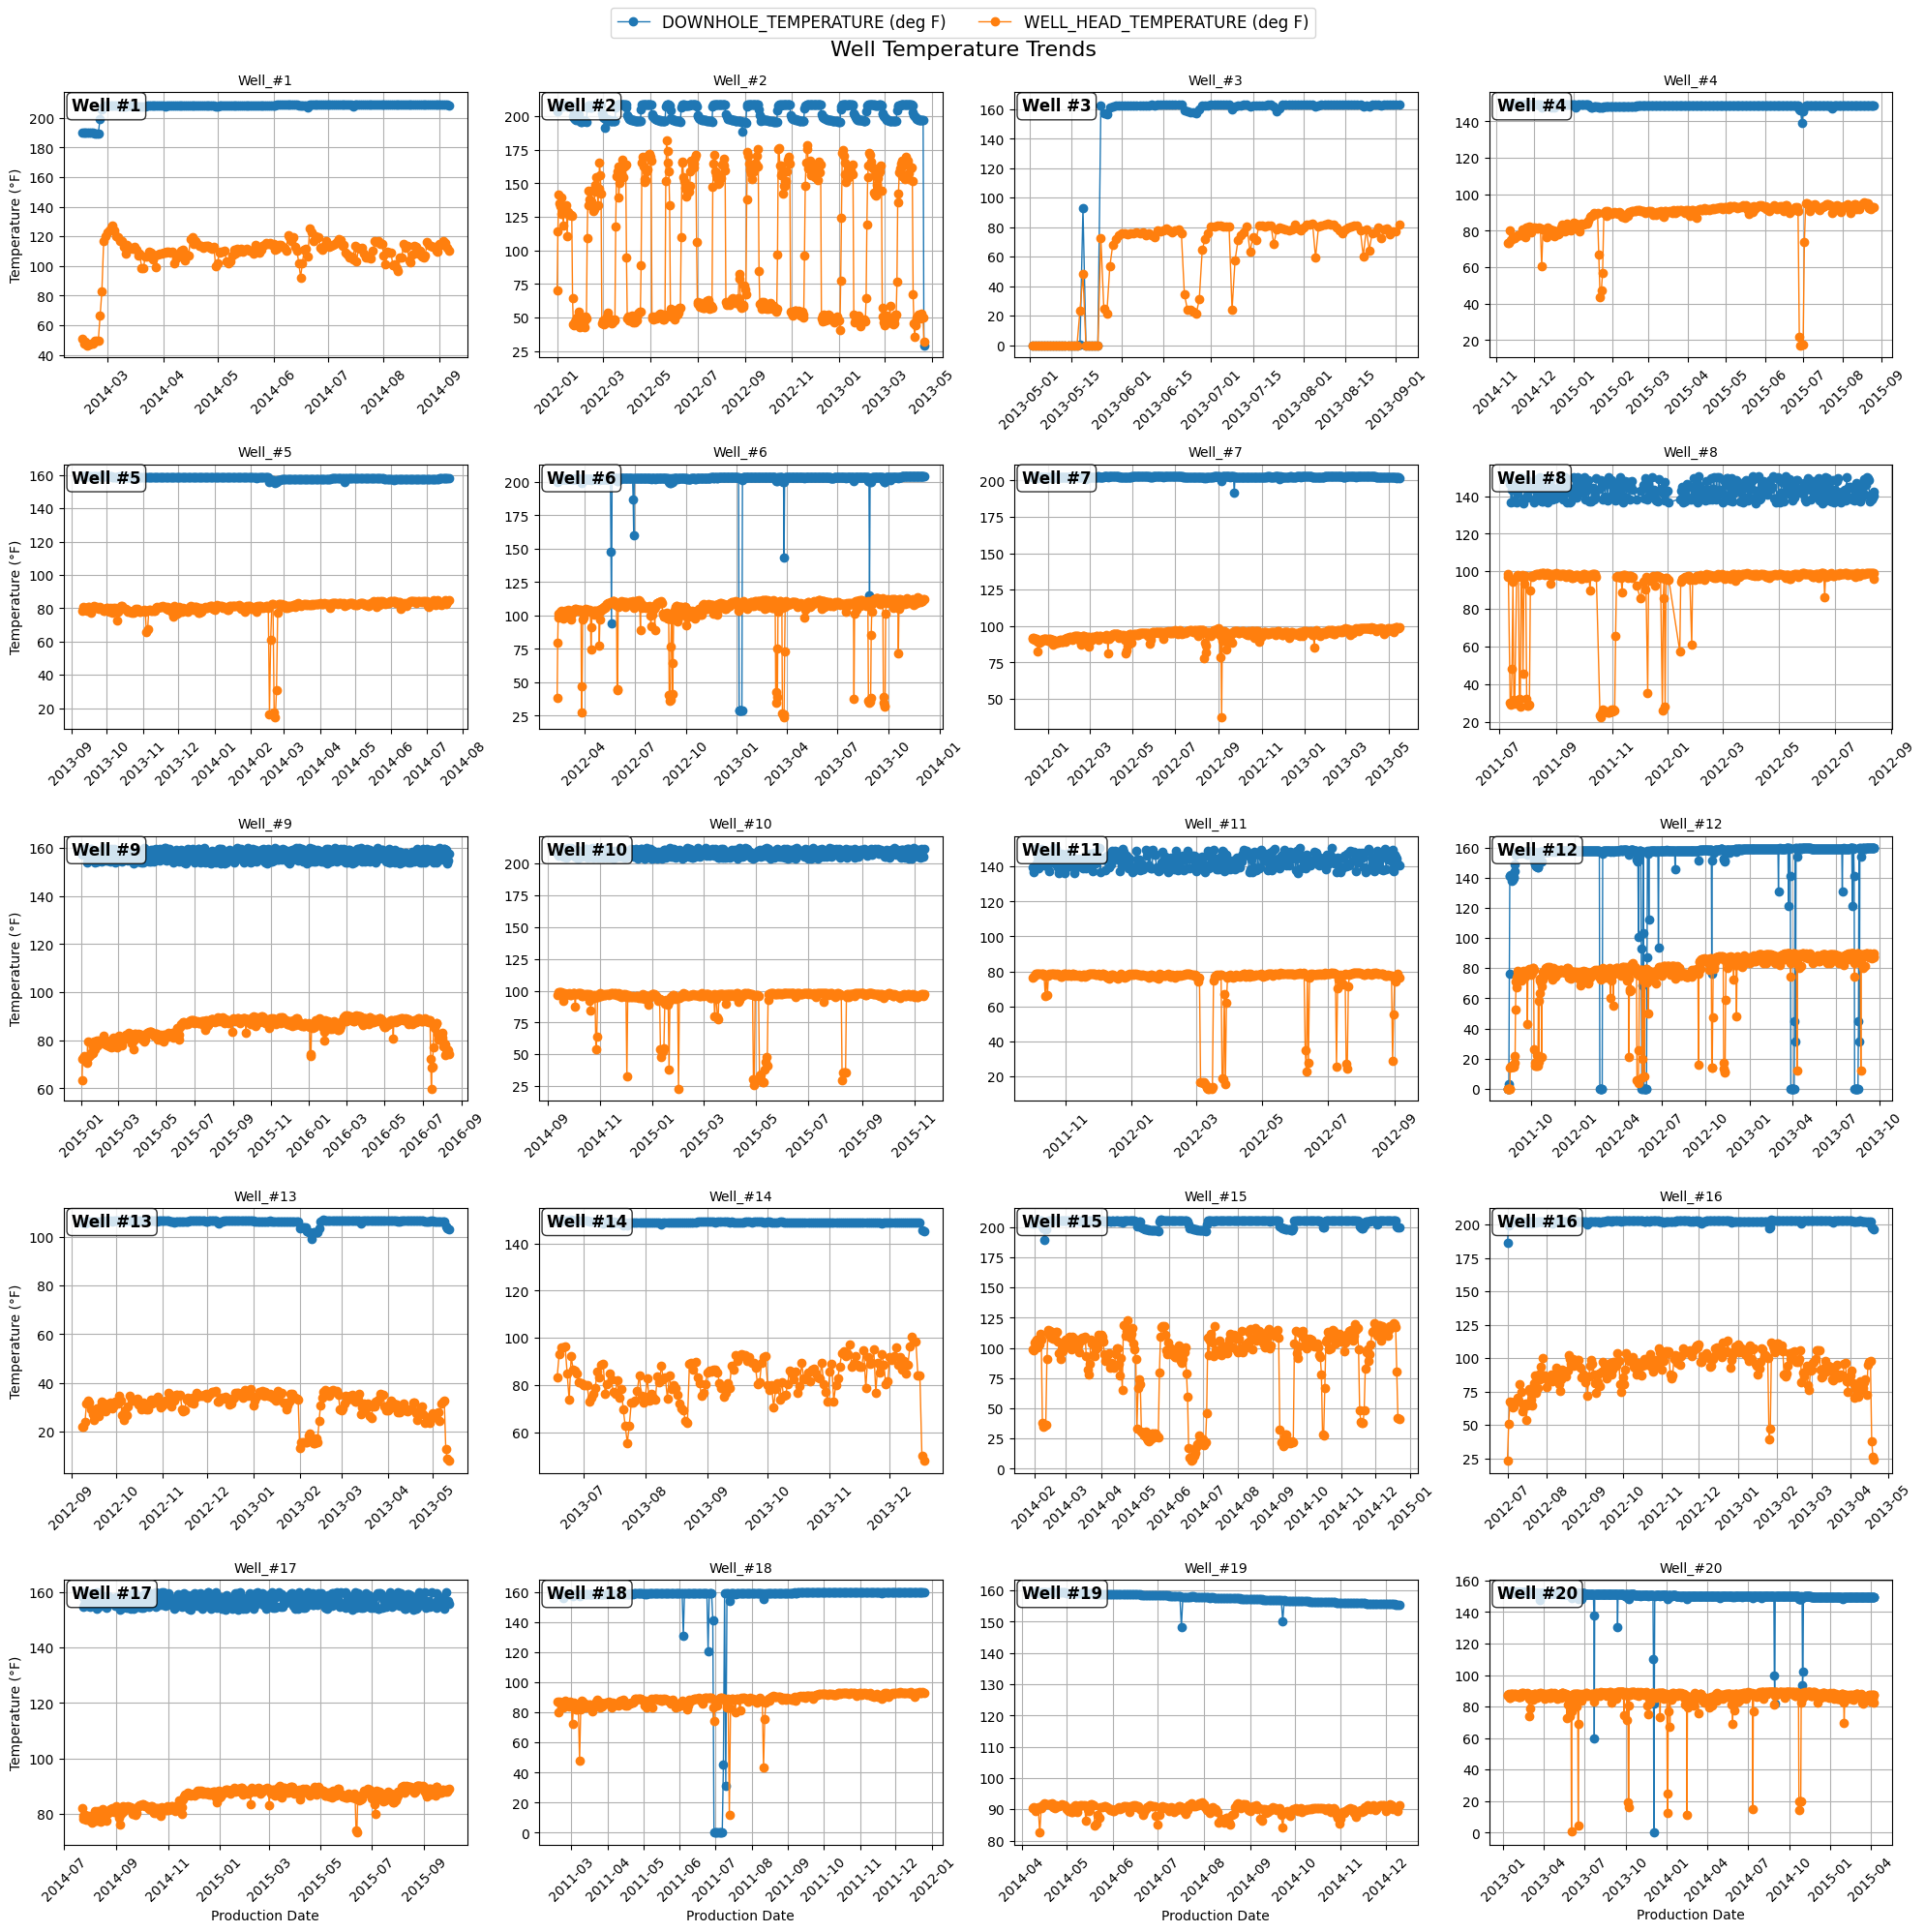

In [34]:
plot_well_time_series(
    well_data=well_data,
    columns=[
        'DOWNHOLE_TEMPERATURE (deg F)',
        'WELL_HEAD_TEMPERATURE (deg F)'
    ],
    title="Well Temperature Trends",
    ylabel="Temperature (°F)",
    show_well_numbers=True,        # Turn on/off well numbers
    text_position=(0.02, 0.98),   # Position as (x, y) in axes coordinates
    text_fontsize=12               # Font size for well numbers
)

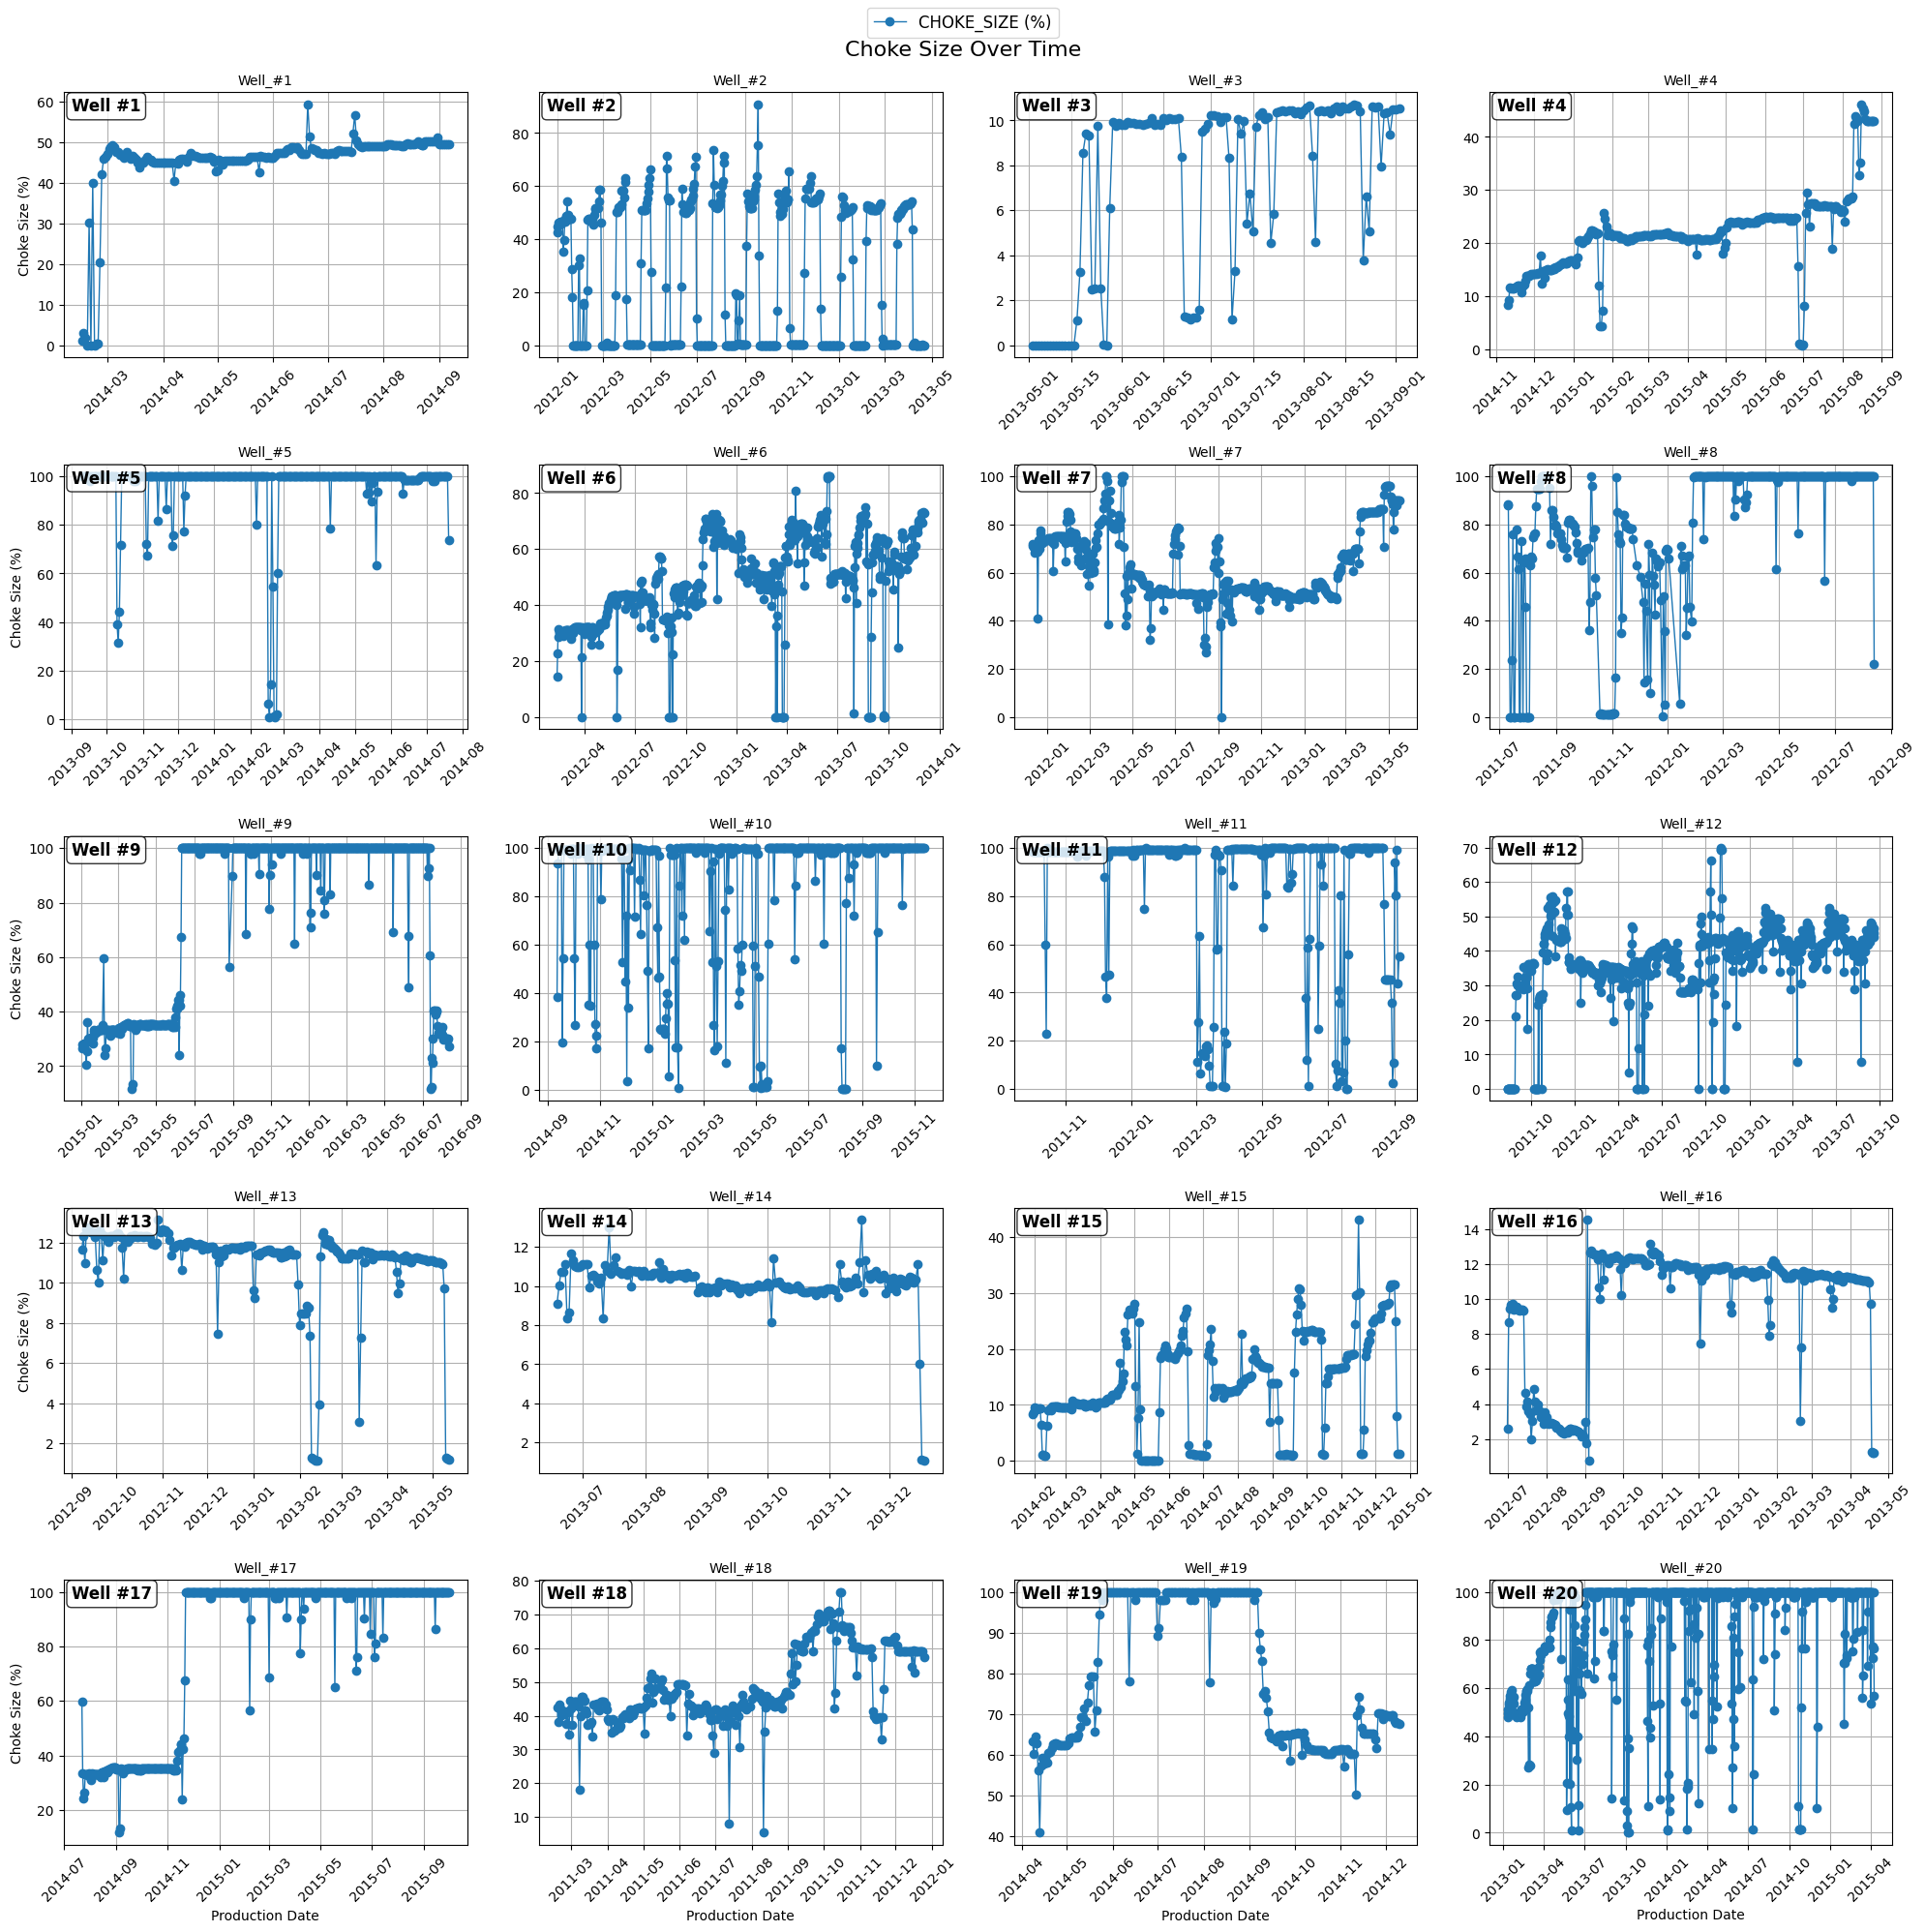

In [35]:
plot_well_time_series(
    well_data=well_data,
    columns=['CHOKE_SIZE (%)'],
    title="Choke Size Over Time",
    ylabel="Choke Size (%)",
    show_well_numbers=True,        # Turn on/off well numbers
    text_position=(0.02, 0.98),   # Position as (x, y) in axes coordinates
    text_fontsize=12               # Font size for well numbers
)

In [36]:
well_data.head(4)

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL),DAY,MONTH,Year
0,2014-02-15,Well_#1,0.0,4050,189.866,0.0,1.17951,482.460,50.864,0,0,0,0,Saturday,February,2014
1,2014-02-16,Well_#1,0.0,3961,189.945,0.0,2.99440,328.601,47.668,0,0,0,0,Sunday,February,2014
2,2014-02-17,Well_#1,0.0,3961,190.004,0.0,1.90349,387.218,48.962,0,0,0,0,Monday,February,2014
3,2014-02-18,Well_#1,0.0,3964,190.020,0.0,0.00000,308.980,46.636,0,0,0,0,Tuesday,February,2014


In [37]:
reservoir_info

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,3500,3300,2700,800,1.20
1,KEMA,4200,4000,3900,600,1.45
2,MAKO,3500,3500,3000,500,1.15
3,DEPU,2800,2800,2400,1200,1.37
4,JANI,4500,4300,4200,1000,1.30
